In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [8]:
file = '../data/merged_redshifts.csv'
df = pd.read_csv(file)
df = df[['photo_redshift', 'photo_redshift_error', 'redshift']]
df = df[(df['photo_redshift'] != -9999.0) & (df['photo_redshift_error'] != -9999.0) & (df['redshift'] != -9999.0)]
df

,photo_redshift,photo_redshift_error,redshift
0,0.124178,0.031162,0.084819
1,0.062380,0.028952,0.094040
2,0.099057,0.027915,0.094277
3,0.034815,0.007055,0.039073
4,0.051839,0.020511,0.039471
...,...,...,...
918,0.278901,0.059075,0.290154
919,0.123785,0.012279,0.101893
920,0.131405,0.025232,0.091725
921,0.095464,0.021486,0.088709


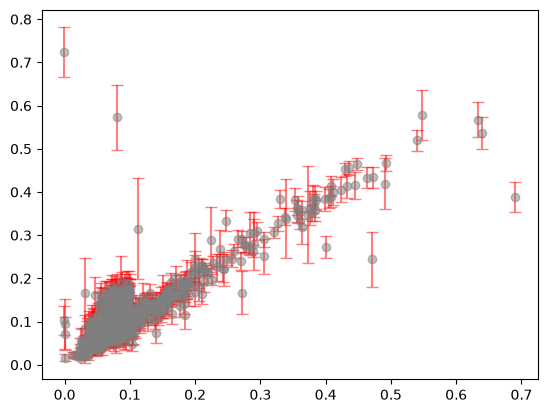

In [9]:
plt.errorbar(df['redshift'], df['photo_redshift'], yerr = df['photo_redshift_error'], fmt = 'o', color = 'gray', alpha = 0.5, ecolor = 'red', capsize = 4, label = 'Data')
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\%'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\%'
C:\Users\nianz\AppData\Local\Temp\ipykernel_15836\662888349.py:34: SyntaxWarning: invalid escape sequence '\s'
  stats_text = (f'$\sigma_{{NMAD}} = {sigma_nmad:.4f}$\n'
C:\Users\nianz\AppData\Local\Temp\ipykernel_15836\662888349.py:35: SyntaxWarning: invalid escape sequence '\%'
  f'$f_{{outlier}} = {f_out:.1f}\%$')


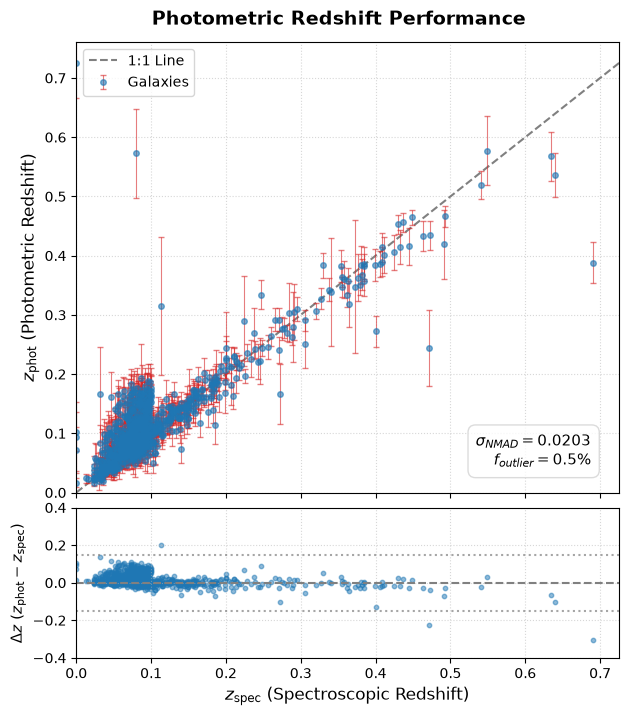

In [10]:
x = df['redshift'].values
y = df['photo_redshift'].values
y_err = df['photo_redshift_error'].values

# 2. 計算天文評估指標 (Delta z = z_phot - z_spec)
dz = y - x
# 天文學標準指標: Normalized Median Absolute Deviation (NMAD)
sigma_nmad = 1.4826 * np.median(np.abs(dz) / (1 + x))
# 離群值比例 (Outlier Fraction, |dz| / (1 + z) > 0.15)
outliers = np.abs(dz) / (1 + x) > 0.15
f_out = np.sum(outliers) / len(x) * 100

# 3. 建立雙子圖結構 (主圖 + 下方殘差圖)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.05) # 緊鄰子圖

# ==================== 主圖 (ax1) ====================
# 畫出 1:1 對角虛線
ax1.plot([0, 1.5], [0, 1.5], color='gray', linestyle='--', linewidth=1.5, label='1:1 Line')

# 繪製帶有誤差線的散點圖
# 調整 markersize (ms), elinewidth, alpha 使其精緻不雜亂
ax1.errorbar(x, y, yerr=y_err, fmt='o', ms=4, color='#1f77b4', 
             ecolor='#d62728', elinewidth=0.8, alpha=0.6, capsize=2, label='Galaxies')

ax1.set_ylabel(r'$z_{\mathrm{phot}}$ (Photometric Redshift)', fontsize=12)
ax1.set_xlim(0, max(x)*1.05)
ax1.set_ylim(0, max(y)*1.05)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.5)

# 在主圖右上角標註科學指標
stats_text = (f'$\sigma_{{NMAD}} = {sigma_nmad:.4f}$\n'
              f'$f_{{outlier}} = {f_out:.1f}\%$')
ax1.text(0.95, 0.05, stats_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'))

# ==================== 殘差圖 (ax2) ====================
# 畫出 Delta z = 0 參考線
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5)
# 畫出 0.15 離群界線
ax2.axhline(0.15, color='gray', linestyle=':', alpha=0.7)
ax2.axhline(-0.15, color='gray', linestyle=':', alpha=0.7)

# 繪製殘差
ax2.scatter(x, dz, color='#1f77b4', alpha=0.5, s=10)

ax2.set_xlabel(r'$z_{\mathrm{spec}}$ (Spectroscopic Redshift)', fontsize=12)
ax2.set_ylabel(r'$\Delta z$ ($z_{\mathrm{phot}} - z_{\mathrm{spec}}$)', fontsize=11)
ax2.set_ylim(-0.4, 0.4)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Photometric Redshift Performance', y=0.92, fontsize=14, fontweight='bold')
plt.show()


<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
C:\Users\nianz\AppData\Local\Temp\ipykernel_15836\3650491810.py:41: SyntaxWarning: invalid escape sequence '\p'
  label=f'Weighted Fit: $y = ({m_best:.2f} \pm {m_err:.2f})x + ({c_best:.2f} \pm {c_err:.2f})$')
C:\Users\nianz\AppData\Local\Temp\ipykernel_15836\3650491810.py:41: SyntaxWarning: invalid escape sequence '\p'
  label=f'Weighted Fit: $y = ({m_best:.2f} \pm {m_err:.2f})x + ({c_best:.2f} \pm {c_err:.2f})$')


擬合結果：
斜率 (Slope m)     = 0.9481 ± 0.0074
截距 (Intercept c) = 0.0092 ± 0.0008


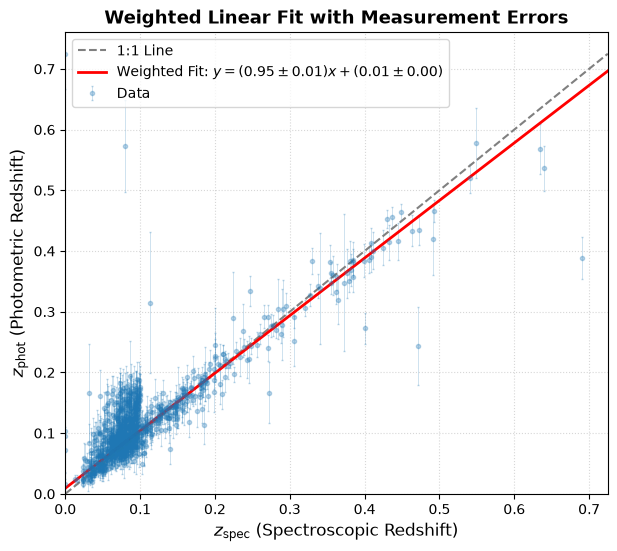

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = df['redshift'].values
y = df['photo_redshift'].values
y_err = df['photo_redshift_error'].values

# 2. 定義線性回歸函數 (y = m * x + c)
def linear_model(x, m, c):
    return m * x + c

# 3. 執行考慮誤差的加權線性擬合
# sigma=y_err 代表將誤差作為權重
# absolute_sigma=True 代表將 y_err 視為真正的物理 1-sigma 不確定性
popt, pcov = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=True)

# 4. 取得最佳擬合參數與其標準誤差 (Standard Errors)
# pcov 的對角線平方根即為參數的誤差
m_best, c_best = popt
m_err, c_err = np.sqrt(np.diag(pcov))

print(f"擬合結果：")
print(f"斜率 (Slope m)     = {m_best:.4f} ± {m_err:.4f}")
print(f"截距 (Intercept c) = {c_best:.4f} ± {c_err:.4f}")

# 5. 繪製圖表
plt.figure(figsize=(7, 6))

# 畫出原始數據點與誤差線 (調淡以突顯擬合線)
plt.errorbar(x, y, yerr=y_err, fmt='o', ms=3, color='#1f77b4', 
             ecolor='#1f77b4', elinewidth=0.5, alpha=0.3, capsize=1, label='Data')

# 畫出 1:1 理想對角虛線作為對照
x_fit = np.linspace(0, max(x)*1.05, 100)
plt.plot(x_fit, x_fit, color='gray', linestyle='--', linewidth=1.5, label='1:1 Line')

# 畫出加權擬合直線
y_fit = linear_model(x_fit, m_best, c_best)
plt.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=2, 
         label=f'Weighted Fit: $y = ({m_best:.2f} \pm {m_err:.2f})x + ({c_best:.2f} \pm {c_err:.2f})$')

# 標註與美化
plt.xlabel(r'$z_{\mathrm{spec}}$ (Spectroscopic Redshift)', fontsize=12)
plt.ylabel(r'$z_{\mathrm{phot}}$ (Photometric Redshift)', fontsize=12)
plt.xlim(0, max(x)*1.05)
plt.ylim(0, max(y)*1.05)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.title('Weighted Linear Fit with Measurement Errors', fontsize=13, fontweight='bold')

plt.show()


<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\%'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\%'
C:\Users\nianz\AppData\Local\Temp\ipykernel_15836\2962114971.py:60: SyntaxWarning: invalid escape sequence '\p'
  stats_text = (f'Fit: $y = ({m_best:.2f} \pm {m_err:.2f})x + ({c_best:.2f} \pm {c_err:.2f})$\n'
C:\Users\nianz\AppData\Local\Temp\ipykernel_15836\2962114971.py:60: SyntaxWarning: invalid escape sequence '\p'
  stats_text = (f'Fit: $y = ({m_best:.2f} \pm {m_err:.2f})x + ({c_best:.2f} \pm {c_err:.2f})$\n'
C:\Users\nianz\AppData\Local\Temp\ipykernel_15836\2962114971.py:61: SyntaxWarning: invalid escape sequence '\s'
  f'$\sigma_{{NMAD}} = {sigma_nmad:.4f}$\n'
C:\Users\nianz\App

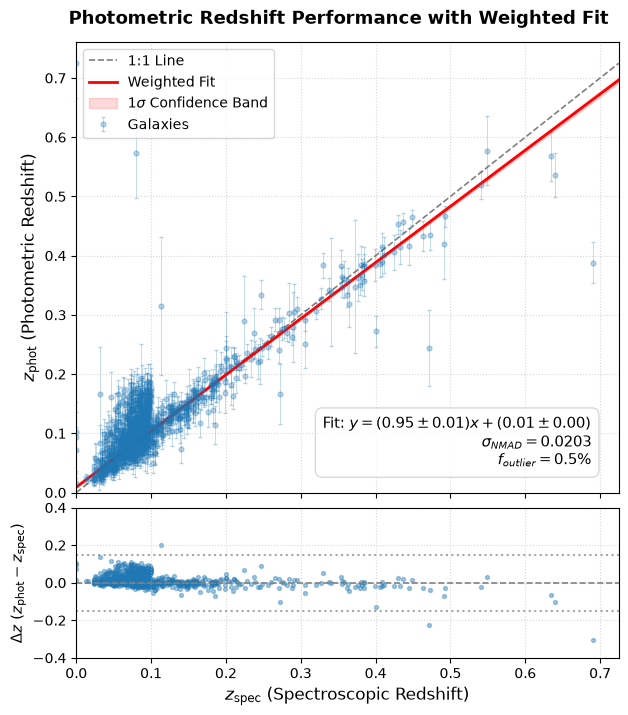

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = df['redshift'].values
y = df['photo_redshift'].values
y_err = df['photo_redshift_error'].values

# 2. 定義線性回歸函數 (y = m * x + c)
def linear_model(x, m, c):
    return m * x + c

# 3. 執行加權線性擬合與計算參數誤差
popt, pcov = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=True)
m_best, c_best = popt
m_err, c_err = np.sqrt(np.diag(pcov))

# 4. 計算天文評估指標 (相對於 1:1 線的殘差)
dz = y - x
sigma_nmad = 1.4826 * np.median(np.abs(dz) / (1 + x))
f_out = np.sum(np.abs(dz) / (1 + x) > 0.15) / len(x) * 100

# 5. 建立雙子圖結構 (主圖 + 下方殘差圖)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.05)

# ==================== 主圖 (ax1) ====================
# A. 繪製 1:1 理想對角虛線
x_fit = np.linspace(0, max(x)*1.05, 100)
ax1.plot(x_fit, x_fit, color='gray', linestyle='--', linewidth=1.2, label='1:1 Line')

# B. 繪製數據點與其誤差線 (將數據點顏色調淡，以突顯擬合直線)
ax1.errorbar(x, y, yerr=y_err, fmt='o', ms=3.5, color='#1f77b4', 
             ecolor='#1f77b4', elinewidth=0.6, alpha=0.3, capsize=1.5, label='Galaxies')

# C. 繪製加權擬合直線 (紅色實線)
y_fit = linear_model(x_fit, m_best, c_best)
ax1.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=2, 
         label=f'Weighted Fit')

# D. 計算並繪製擬合線掃過的 1-sigma 誤差區域 (Confidence Band)
# 根據誤差傳播公式計算每個 x 點的預測不確定度
var_m = pcov[0, 0]
var_c = pcov[1, 1]
cov_mc = pcov[0, 1]
y_fit_err = np.sqrt(x_fit**2 * var_m + var_c + 2 * x_fit * cov_mc)

# 繪製半透明紅色填充區域
ax1.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err, 
                 color='red', alpha=0.15, label=r'$1\sigma$ Confidence Band')

ax1.set_ylabel(r'$z_{\mathrm{phot}}$ (Photometric Redshift)', fontsize=12)
ax1.set_xlim(0, max(x)*1.05)
ax1.set_ylim(0, max(y)*1.05)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.5)

# 右下角標註科學指標與擬合公式
stats_text = (f'Fit: $y = ({m_best:.2f} \pm {m_err:.2f})x + ({c_best:.2f} \pm {c_err:.2f})$\n'
              f'$\sigma_{{NMAD}} = {sigma_nmad:.4f}$\n'
              f'$f_{{outlier}} = {f_out:.1f}\%$')
ax1.text(0.95, 0.05, stats_text, transform=ax1.transAxes, fontsize=10.5,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='lightgray'))

# ==================== 殘差圖 (ax2) ====================
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.2)
ax2.axhline(0.15, color='gray', linestyle=':', alpha=0.7)
ax2.axhline(-0.15, color='gray', linestyle=':', alpha=0.7)

# 繪製殘差
ax2.scatter(x, dz, color='#1f77b4', alpha=0.4, s=8)

ax2.set_xlabel(r'$z_{\mathrm{spec}}$ (Spectroscopic Redshift)', fontsize=12)
ax2.set_ylabel(r'$\Delta z$ ($z_{\mathrm{phot}} - z_{\mathrm{spec}}$)', fontsize=11)
ax2.set_ylim(-0.4, 0.4)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Photometric Redshift Performance with Weighted Fit', y=0.92, fontsize=13, fontweight='bold')
plt.show()
